In [39]:
import pandas as pd
import yaml
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px


In [2]:
with open("../config.yaml", "r") as file:
    config = yaml.safe_load(file)


In [3]:
config

{'input_data': {'file1': '../data/raw/Beginner_Climate_Change_Dataset_20_Features_1200_Rows.csv',
  'file2': '../data/raw/realistic_ocean_climate_dataset.csv',
  'file3': '../data/raw/ocean_health_index.csv',
  'file4': '../data/raw/global_bleaching_environmental.csv'},
 'output_data': {'file': '../data/clean/cleaned_data_file.csv'}}

In [4]:
df = pd.read_csv(config["input_data"]["file2"])

In [5]:
df.head()

,Date,Location,Latitude,Longitude,SST (°C),pH Level,Bleaching Severity,Species Observed,Marine Heatwave
0,2015-01-01,Red Sea,20.0248,38.4931,29.47,8.107,NaN,106,False
1,2015-01-07,Great Barrier Reef,-18.2988,147.7782,29.65,8.004,High,116,False
2,2015-01-14,Caribbean Sea,14.9768,-75.0233,28.86,7.947,High,90,False
3,2015-01-20,Great Barrier Reef,-18.3152,147.6486,28.97,7.995,Medium,94,False
4,2015-01-27,Galápagos,-0.8805,-90.9769,28.60,7.977,NaN,110,False


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                500 non-null    str    
 1   Location            500 non-null    str    
 2   Latitude            500 non-null    float64
 3   Longitude           500 non-null    float64
 4   SST (°C)            500 non-null    float64
 5   pH Level            500 non-null    float64
 6   Bleaching Severity  350 non-null    str    
 7   Species Observed    500 non-null    int64  
 8   Marine Heatwave     500 non-null    bool   
dtypes: bool(1), float64(4), int64(1), str(3)
memory usage: 31.9 KB


We only have missing values in 'Bleaching Severity', however it represents 30% of the dataframe.

In [7]:
df['Location'].unique()

<StringArray>
[           'Red Sea', 'Great Barrier Reef',      'Caribbean Sea',
          'Galápagos',    'South China Sea',           'Maldives',
   'Hawaiian Islands']
Length: 7, dtype: str

In [8]:
grouped = df.groupby('Location')
grouped

In [34]:
for location, group in grouped:
    print(f"Location: {location}")
    display(group.head(3))

Location: Caribbean Sea


,Date,Location,Latitude,Longitude,SST (°C),pH Level,Bleaching Severity,Species Observed,Marine Heatwave,Bleaching Numeric
2,2015-01-14,Caribbean Sea,14.9768,-75.0233,28.86,7.947,High,90,False,3.0
9,2015-03-01,Caribbean Sea,14.9640,-75.0230,30.09,8.035,High,77,True,3.0
11,2015-03-14,Caribbean Sea,15.0466,-75.0420,28.04,8.076,High,139,False,3.0


Location: Galápagos


,Date,Location,Latitude,Longitude,SST (°C),pH Level,Bleaching Severity,Species Observed,Marine Heatwave,Bleaching Numeric
4,2015-01-27,Galápagos,-0.8805,-90.9769,28.60,7.977,NaN,110,False,NaN
10,2015-03-07,Galápagos,-0.9376,-90.9849,27.48,8.101,NaN,145,False,NaN
12,2015-03-21,Galápagos,-0.9778,-90.9749,26.84,8.023,NaN,148,False,NaN


Location: Great Barrier Reef


...

,Date,Location,Latitude,Longitude,SST (°C),pH Level,Bleaching Severity,Species Observed,Marine Heatwave,Bleaching Numeric
8,2015-02-22,Maldives,3.2397,73.2293,28.33,8.038,Low,99,False,1.0
19,2015-05-06,Maldives,3.1296,73.2355,28.89,8.042,Low,112,False,1.0
29,2015-07-10,Maldives,3.2419,73.1589,26.52,8.116,High,144,False,3.0


Location: Red Sea


,Date,Location,Latitude,Longitude,SST (°C),pH Level,Bleaching Severity,Species Observed,Marine Heatwave,Bleaching Numeric
0,2015-01-01,Red Sea,20.0248,38.4931,29.47,8.107,NaN,106,False,NaN
5,2015-02-02,Red Sea,20.0055,38.4425,29.06,8.009,Low,109,False,1.0
7,2015-02-16,Red Sea,19.9390,38.5104,25.56,8.042,Low,152,False,1.0


Location: South China Sea


,Date,Location,Latitude,Longitude,SST (°C),pH Level,Bleaching Severity,Species Observed,Marine Heatwave,Bleaching Numeric
6,2015-02-09,South China Sea,9.9699,115.0926,28.48,7.998,NaN,132,False,NaN
13,2015-03-27,South China Sea,10.0678,114.9964,30.01,8.038,High,95,True,3.0
15,2015-04-09,South China Sea,10.0411,115.0044,28.05,8.064,Medium,94,False,2.0


In [10]:
grouped.get_group('Great Barrier Reef').info()

<class 'pandas.DataFrame'>
Index: 87 entries, 1 to 494
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                87 non-null     str    
 1   Location            87 non-null     str    
 2   Latitude            87 non-null     float64
 3   Longitude           87 non-null     float64
 4   SST (°C)            87 non-null     float64
 5   pH Level            87 non-null     float64
 6   Bleaching Severity  62 non-null     str    
 7   Species Observed    87 non-null     int64  
 8   Marine Heatwave     87 non-null     bool   
dtypes: bool(1), float64(4), int64(1), str(3)
memory usage: 6.2 KB


In [11]:
gbr_df = grouped.get_group('Great Barrier Reef').copy()

# Display all rows as a DataFrame temporarily
#with pd.option_context('display.max_rows', None, 'display.max_columns', None):
#    display(gbr_df)

Let's analyse our first hypothesis: 
- Reefs in the Great Barrier Reef experiencing higher sea surface temperatures and marine heatwaves will show greater coral bleaching severity and lower numbers of marine species observed. 

Analysing hipothesis 1 in Great Barrier Reef with missing values.

- Test Sea Surface Temperature vs Bleaching Severity

<Axes: xlabel='Bleaching Severity', ylabel='SST (°C)'>

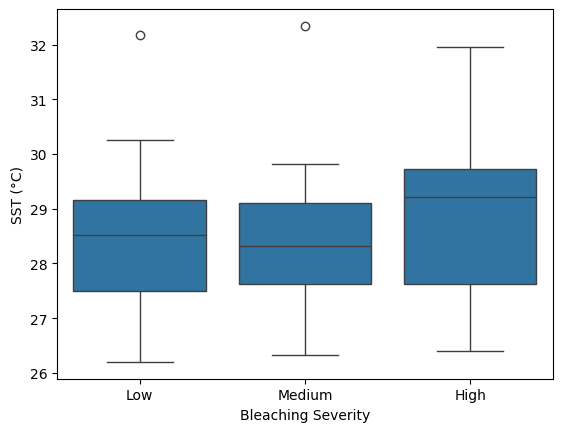

In [ ]:
bleaching_order = ['Low', 'Medium', 'High']
gbr_df['Bleaching Severity'] = pd.Categorical(gbr_df['Bleaching Severity'], categories=bleaching_order, ordered=True)

# Calculate mean SST per bleaching severity
mean_sst = gbr_df.groupby('Bleaching Severity')['SST (°C)'].mean().reset_index()

# Plot line chart
sns.boxplot(data=gbr_df, x='Bleaching Severity', y='SST (°C)')

Analysing hipothesis 1 in Great Barrier Reef replacing the missing values with the previous value. If bleaching severity wasn't recorded on a date, it likely remained the same as the previous observation at that reef.

<class 'pandas.Series'>
Index: 87 entries, 1 to 494
Series name: Bleaching Severity
Non-Null Count  Dtype   
--------------  -----   
87 non-null     category
dtypes: category(1)
memory usage: 915.0 bytes


<Axes: title={'center': 'SST vs Bleaching'}, xlabel='Bleaching Severity', ylabel='SST (°C)'>

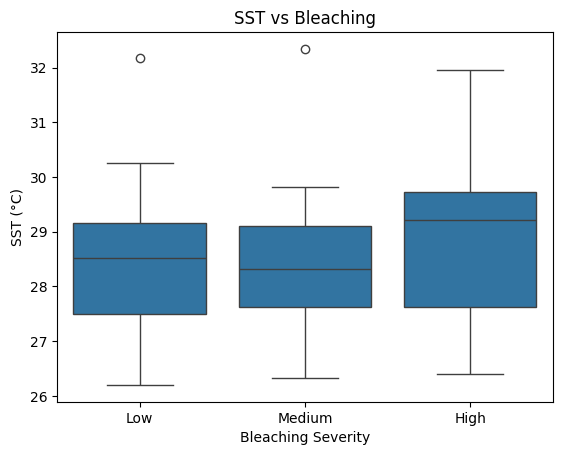

In [13]:
gbr_df['Bleaching Severity'] = gbr_df['Bleaching Severity'].ffill()
gbr_df['Bleaching Severity'].info()

bleaching_order = ['Low', 'Medium', 'High']
gbr_df['Bleaching Severity'] = pd.Categorical(gbr_df['Bleaching Severity'], categories=bleaching_order, ordered=True)

# Calculate mean SST per bleaching severity
mean_sst = gbr_df.groupby('Bleaching Severity')['SST (°C)'].mean().reset_index()

# Box-plot
plt.title('SST vs Bleaching')
sns.boxplot(data=gbr_df, x='Bleaching Severity', y='SST (°C)')

Since the results were the same, we will continue our analysis with the missing values replaced.

The boxplot indicates that higher coral bleaching severity is generally associated with slightly higher sea surface temperatures. Reefs classified with high bleaching severity show a higher median SST compared to low and medium categories. Although the temperature ranges overlap, the overall pattern suggests that increased ocean temperatures contribute to more severe coral bleaching events.

- Test bleaching severity vs number of species:

<Axes: xlabel='Bleaching Severity', ylabel='Species Observed'>

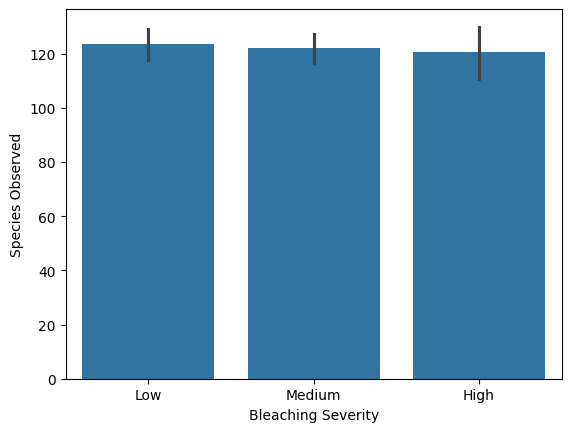

In [14]:
mean_species = gbr_df.groupby('Bleaching Severity')['Species Observed'].mean().reset_index()

sns.barplot(
    data=gbr_df,
    x='Bleaching Severity',
    y='Species Observed',
    order=['Low','Medium','High']
)

While higher temperatures are associated with increased bleaching severity, the number of species observed does not decline strongly with bleaching severity in this dataset.

- Test Sea Surface Temperature vs species count

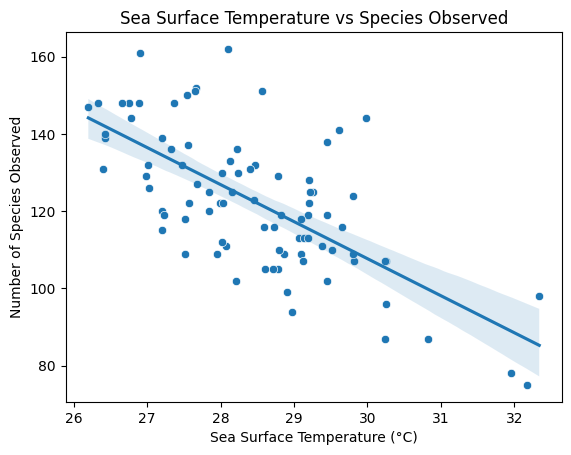

In [15]:
sns.scatterplot(data=gbr_df, x='SST (°C)', y='Species Observed')
sns.regplot(data=gbr_df, x='SST (°C)', y='Species Observed', scatter=False)

plt.title('Sea Surface Temperature vs Species Observed')
plt.xlabel('Sea Surface Temperature (°C)')
plt.ylabel('Number of Species Observed')
plt.show()

The scatterplot shows a clear negative relationship between sea surface temperature and the number of marine species observed. As SST increases, species counts tend to decrease, indicating that warmer ocean temperatures may reduce marine biodiversity in the Great Barrier Reef. This finding supports the hypothesis that elevated sea surface temperatures are associated with lower species observations.

- Test heatwave intensity vs bleaching:

In [16]:
severity_map = {'Low':1, 'Medium':2, 'High':3}

gbr_df['Bleaching Numeric'] = gbr_df['Bleaching Severity'].map(severity_map).astype(int)

gbr_df.groupby('Marine Heatwave')['Bleaching Numeric'].mean().reset_index()

,Marine Heatwave,Bleaching Numeric
0,False,1.772152
1,True,1.625000


In [17]:
gbr_df['Marine Heatwave'].value_counts()

Marine Heatwave
False    79
True      8
Name: count, dtype: int64

In [18]:
pd.crosstab(gbr_df['Marine Heatwave'], gbr_df['Bleaching Severity'])

Bleaching Severity,Low,Medium,High
Marine Heatwave,,,
False,31,35,13
True,5,1,2


<Axes: xlabel='Bleaching Severity', ylabel='count'>

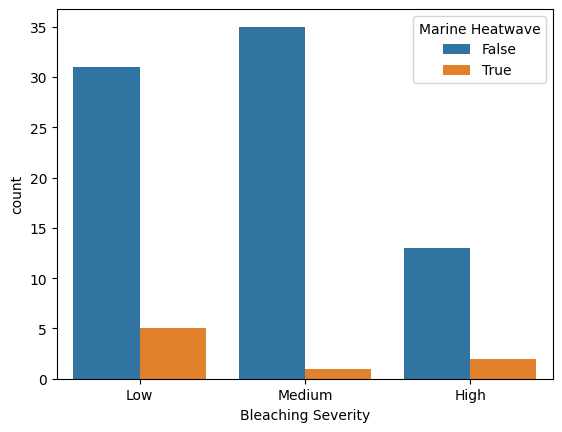

In [ ]:
sns.countplot(
    data=gbr_df,
    x='Bleaching Severity',
    hue='Marine Heatwave',
    order=['Low','Medium','High']
)

As there are very few heatwave observations, the result will not be reliable. Bleaching may respond to sustained heat, not just a boolean heatwave indicator. Other factors affect bleaching, such as solar radiation, water depth, coral species resilience and ocean acidity (pH).
The average bleaching severity was slightly higher during periods without marine heatwaves (mean = 1.77) compared to periods with marine heatwaves (mean = 1.63). This suggests that, within this dataset, marine heatwave occurrence alone does not strongly explain variation in bleaching severity.

In [ ]:
# Create summary table
results = {
    "Relationship": [
        "SST → Bleaching severity",
        "SST → Species observed",
        "Bleaching severity → Species observed",
        "Marine heatwaves → Bleaching severity"
    ],
    "Result": [
        "Supported",
        "Strong negative relationship",
        "Weak negative relationship",
        "Not clearly supported"
    ]
}

results_table = pd.DataFrame(results)

# Display the table
results_table

,Relationship,Result
0,SST → Bleaching severity,Supported
1,SST → Species observed,Strong negative relationship
2,Bleaching severity → Species observed,Weak negative relationship
3,Marine heatwaves → Bleaching severity,Not clearly supported


1st Hypothesis Conclusion: The analysis indicates that higher sea surface temperatures are associated with increased coral bleaching severity and lower numbers of observed marine species. While bleaching severity shows a slight decline in species counts, the strongest relationship observed in the dataset is between increasing SST and decreasing biodiversity. Marine heatwaves did not show a strong influence on bleaching severity within this dataset.

Let's test the second hypothesis:
- Marine heatwaves and elevated sea surface temperatures are associated with a decrease in the number of marine species observed.

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                500 non-null    str    
 1   Location            500 non-null    str    
 2   Latitude            500 non-null    float64
 3   Longitude           500 non-null    float64
 4   SST (°C)            500 non-null    float64
 5   pH Level            500 non-null    float64
 6   Bleaching Severity  350 non-null    str    
 7   Species Observed    500 non-null    int64  
 8   Marine Heatwave     500 non-null    bool   
dtypes: bool(1), float64(4), int64(1), str(3)
memory usage: 31.9 KB


In [22]:
# Since we are using all locations, let's fill in the missing values for each location
df['Bleaching Severity'] = (
    df.sort_values('Date')
      .groupby('Location')['Bleaching Severity']
      .ffill()
)

In [42]:
#safe clean df to folder clean data
df.to_csv('ocean_climate_clean.csv', index=False)

In [23]:
df.info() #we still have 5 missing values because are the first values for some locations that don't have a previous value to be replaced with

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                500 non-null    str    
 1   Location            500 non-null    str    
 2   Latitude            500 non-null    float64
 3   Longitude           500 non-null    float64
 4   SST (°C)            500 non-null    float64
 5   pH Level            500 non-null    float64
 6   Bleaching Severity  495 non-null    str    
 7   Species Observed    500 non-null    int64  
 8   Marine Heatwave     500 non-null    bool   
dtypes: bool(1), float64(4), int64(1), str(3)
memory usage: 31.9 KB


In [24]:
print(df[['Species Observed', 'SST (°C)', 'Marine Heatwave']].describe())
print(df['Marine Heatwave'].value_counts())

       Species Observed    SST (°C)
count        500.000000  500.000000
mean         120.472000   28.537200
std           20.475441    1.425076
min           54.000000   23.640000
25%          107.750000   27.530000
50%          120.000000   28.515000
75%          133.250000   29.452500
max          171.000000   33.210000
Marine Heatwave
False    427
True      73
Name: count, dtype: int64


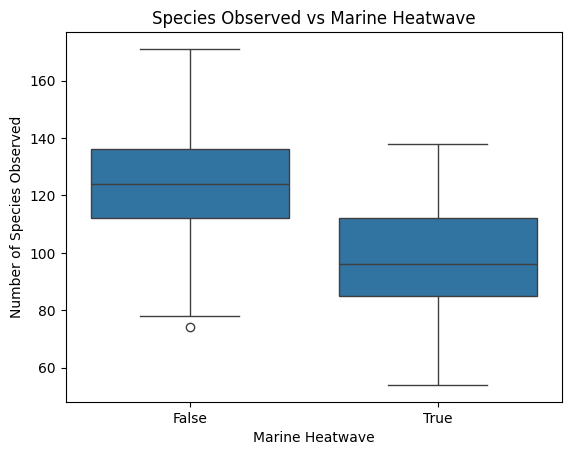

In [ ]:
# species observed vs marine heatwave
sns.boxplot(x='Marine Heatwave', y='Species Observed', data=df)
plt.title('Species Observed vs Marine Heatwave')
plt.ylabel('Number of Species Observed')
plt.xlabel('Marine Heatwave')
plt.show()

This show that species counts tend to be lower during heatwaves.

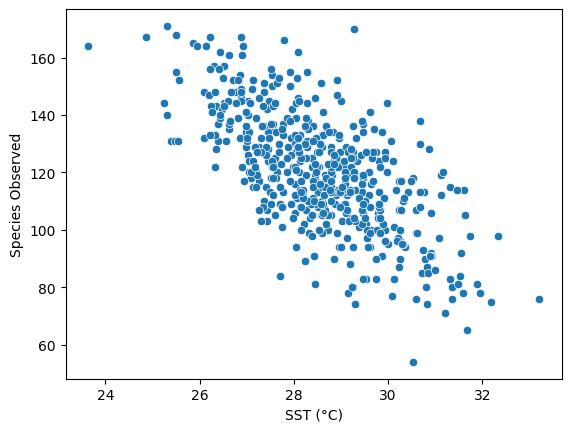

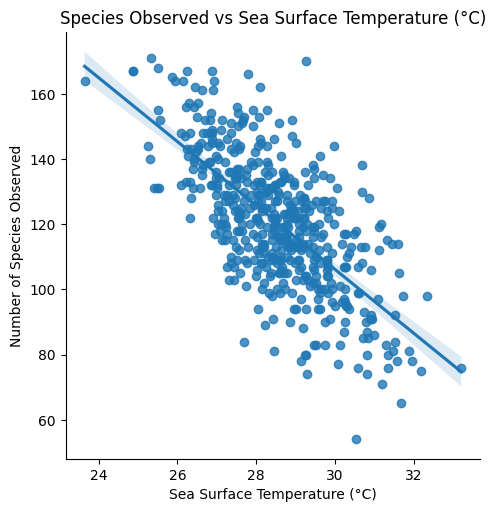

In [26]:
# species observed vs sst
sns.scatterplot(x='SST (°C)', y='Species Observed', data=df)
sns.lmplot(x='SST (°C)', y='Species Observed', data=df)
plt.title('Species Observed vs Sea Surface Temperature (°C)')
plt.xlabel('Sea Surface Temperature (°C)')
plt.ylabel('Number of Species Observed')
plt.show()

This shows that the number os species observed decreases with the rise of sea surface temperature.

In [27]:
mean_species = df.groupby('Marine Heatwave')['Species Observed'].mean()
print(mean_species)

Marine Heatwave
False    124.377049
True      97.630137
Name: Species Observed, dtype: float64


As mean species observed is lower during heatwaves, it supports our hypothesis.

In [28]:
correlation = df['SST (°C)'].corr(df['Species Observed'])
print(f"Correlation between SST and Species Observed: {correlation:.3f}")

Correlation between SST and Species Observed: -0.681


Negative correlation → higher SST associated with fewer species.

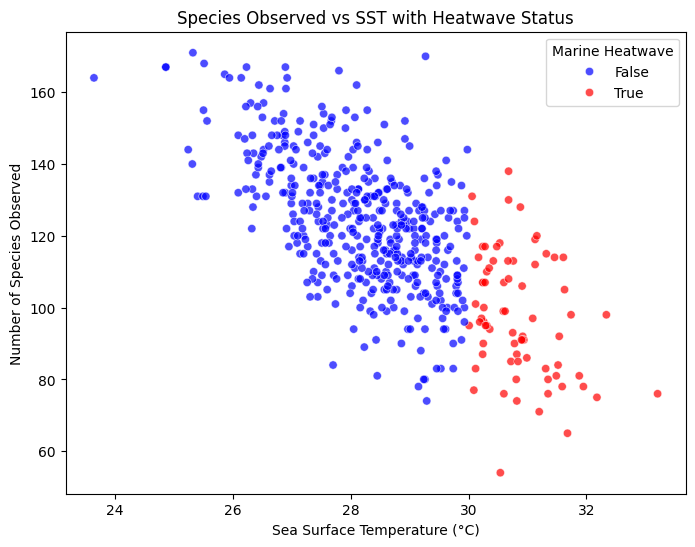

In [ ]:
# Combine heatwave (categorical) and SST (continuous) in a single analysis for stronger evidence.

# Scatter plot: Species Observed vs SST, color = Marine Heatwave
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='SST (°C)',
    y='Species Observed',
    hue='Marine Heatwave',
    data=df,
    palette={True:'red', False:'blue'},
    alpha=0.7
)

plt.title('Species Observed vs SST with Heatwave Status')
plt.xlabel('Sea Surface Temperature (°C)')
plt.ylabel('Number of Species Observed')
plt.legend(title='Marine Heatwave')
plt.show()

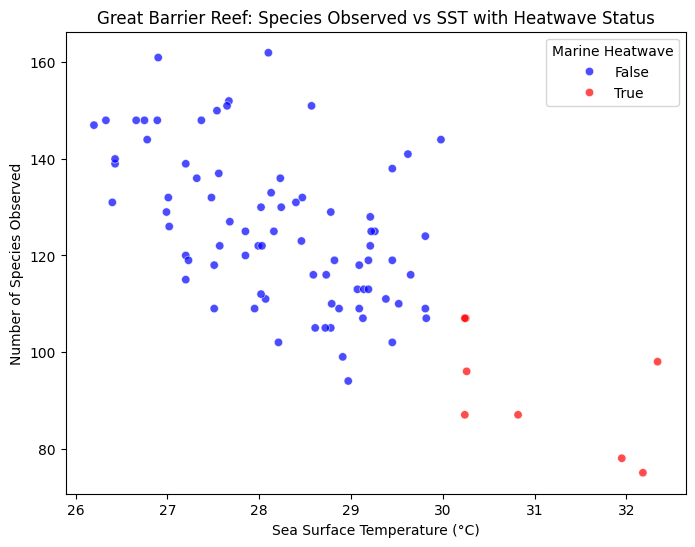

In [ ]:
# Scatter plot: Species Observed vs SST, color = Marine Heatwave
# Great barrier reef variant
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='SST (°C)',
    y='Species Observed',
    hue='Marine Heatwave',
    data=gbr_df,
    palette={True:'red', False:'blue'},
    alpha=0.7
)

plt.title('Great Barrier Reef: Species Observed vs SST with Heatwave Status')
plt.xlabel('Sea Surface Temperature (°C)')
plt.ylabel('Number of Species Observed')
plt.legend(title='Marine Heatwave')
plt.show()

Our analysis supports the hypothesis that marine heatwaves and elevated sea surface temperatures are associated with a decrease in the number of marine species observed. Scatter plots and regression analyses showed that species counts were generally lower during heatwave conditions compared to non-heatwave periods, even at similar SST levels. Additionally, the mean number of species observed declined as SST increased, with the effect more pronounced during heatwave events. These results provide strong evidence that both elevated temperatures and heatwaves negatively impact marine biodiversity in the reef ecosystem.

In [38]:
severity_map = {'Low':1, 'Medium':2, 'High':3}
df['Bleaching Numeric'] = df['Bleaching Severity'].map(severity_map)

In [40]:
map_df = df.groupby('Location').agg({
    'Latitude':'first',
    'Longitude':'first',
    'SST (°C)':'mean',
    'Bleaching Numeric':'mean'
}).reset_index()

fig = px.scatter_geo(
    df,
    lat='Latitude',
    lon='Longitude',
    color='Bleaching Numeric',
    size='SST (°C)',
    hover_name='Location',
    title='Coral Bleaching Severity Across Reef Locations',
    color_continuous_scale='Reds'
)

fig.show()

Your first hypothesis tested:

- Reefs in the Great Barrier Reef experiencing higher SST and marine heatwaves will show greater bleaching severity and lower numbers of marine species observed.

However, your results showed:

SST → bleaching: supported

Marine heatwaves → bleaching: not clearly supported

The map helps explain why.

1️⃣ Bleaching severity varies across locations

The map shows that bleaching severity is not uniform across reefs worldwide.

Some locations experience stronger bleaching impacts than others.

This suggests that local environmental factors influence bleaching responses.